<a href="https://colab.research.google.com/github/csorty/car/blob/main/dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


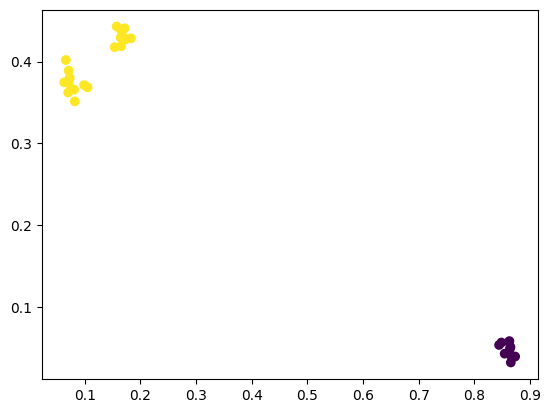

In [ ]:
import random
import pygame
import math
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

def generate_points(count_of_centers = 3, count_of_point = 10):
    points = []
    for _ in range(count_of_centers):
        centerX, centerY = random.random(), random.random()
        for _ in range(count_of_point):
            points.append(Point(
                random.gauss(centerX, 0.01),
                random.gauss(centerY, 0.01)
            ))
    return points



def main():
    points = generate_points()
    pointXY = np.array([[p.x, p.y] for p in points])

    dbscan = DBSCAN(eps=0.1, min_samples=3)
    labels = dbscan.division(pointXY)

    plt.scatter(pointXY[:, 0], pointXY[:, 1], c=labels)
    plt.show()

def my_pygame():
    pygame.init()
    screen = pygame.display.set_mode((600, 400))
    while True:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                exit()

class DBSCAN:
    def __init__(self, eps, min_samples):
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None
        self.cluster_cnt = 0

    def distance(self, p1, p2):
        spacing = (p1[0] - p2[0])**2 + (p1[1] - p2[1])**2
        return math.sqrt(spacing)

    def find_neighbors(self, points, point_idx):
        neighbors = []
        for i in range(len(points)):
            if i != point_idx:
                if self.distance(points[point_idx], points[i]) <= self.eps:
                    neighbors.append(i)
        return neighbors

    def division(self, points):
        n = len(points)
        self.labels = [0] * n
        self.cluster_cnt = 0

        for i in range(n):
            if self.labels[i] != 0:
                continue

            neighbors = self.find_neighbors(points, i)

            if len(neighbors) < self.min_samples:
                self.labels[i] = -1
            else:
                self.cluster_cnt += 1
                self.search_cluster(points, i, neighbors, self.cluster_cnt)
        return np.array(self.labels)

    def search_cluster(self, points, point_idx, neighbors, cluster_label):
        self.labels[point_idx] = cluster_label
        queue = deque(neighbors)
        parsed = {point_idx}

        while queue:
            current = queue.popleft()
            if current in parsed:
                continue
            parsed.add(current)

            if self.labels[current] == -1:
                self.labels[current] = cluster_label

            if self.labels[current] == 0:
                self.labels[current] = cluster_label

                current_neighbors = self.find_neighbors(points, current)

                if len(current_neighbors) >= self.min_samples:
                    for neighbor in current_neighbors:
                        if neighbor not in parsed and neighbor not in queue:
                            queue.append(neighbor)

if __name__ == '__main__':
    main()